# Inside Airbnb Tokyo: テキスト・数値・カテゴリを使った価格予測のためのEDA

このノートブックでは、Inside Airbnb の **Tokyo `listings.csv.gz`（Detailed Listings data）** を直接読み込み、価格予測タスクのための簡単なEDAを行います。

想定タスク：

- **目的変数**: `price`
- **テキスト特徴量**: `name`, `description`, `neighborhood_overview`, `host_about`
- **数値特徴量**: 宿泊人数、寝室数、レビュー数、緯度経度など
- **カテゴリ特徴量**: 部屋タイプ、物件タイプ、地域、スーパーホスト等


In [5]:
# 必要なライブラリ
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 160)

print('Setup complete')

Setup complete


## 1. データの読み込み

Inside Airbnb の Tokyo `listings.csv.gz` を直接読み込みます。

日付入りURLは将来変わる可能性があるため、読み込みに失敗した場合は https://insideairbnb.com/get-the-data/ で Tokyo の `listings.csv.gz` のURLを確認し、`DATA_URL` を差し替えてください。

In [ ]:
DATA_URL = 'https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/2026-06-30/data/listings.csv.gz'

# 読み込み
raw = pd.read_csv(DATA_URL, compression='gzip', low_memory=False)

print(raw.shape)
raw.head()

## 2. 主要カラムの確認

価格予測に使いやすいカラムを、テキスト・数値・カテゴリに分けて確認します。

In [ ]:
target_col = 'price'

text_cols = [
    'name',
    'description',
    'neighborhood_overview',
    'host_about',
]

numeric_cols = [
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'minimum_nights',
    'maximum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'reviews_per_month',
    'availability_365',
    'latitude',
    'longitude',
    'host_listings_count',
]

categorical_cols = [
    'room_type',
    'property_type',
    'neighbourhood_cleansed',
    'host_is_superhost',
    'instant_bookable',
]

selected_cols = [target_col] + text_cols + numeric_cols + categorical_cols
available_cols = [c for c in selected_cols if c in raw.columns]
missing_cols = [c for c in selected_cols if c not in raw.columns]

print('Available columns:', len(available_cols))
print(available_cols)
print('Missing columns:', missing_cols)

raw[available_cols].head()

## 3. 価格 `price` の前処理

`price` は `$12,345` のような文字列で入っていることがあるため、数値に変換します。極端な外れ値の影響を見やすくするため、EDA用に `log_price` も作ります。

In [8]:
df = raw[available_cols].copy()

def clean_price(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    x = str(x)
    x = re.sub(r'[^0-9.]', '', x)
    return float(x) if x else np.nan

df['price_num'] = df['price'].apply(clean_price)

# 価格が0以下・欠損の行は回帰タスクでは使いにくいので除外
df = df[df['price_num'].notna() & (df['price_num'] > 0)].copy()
df['log_price'] = np.log1p(df['price_num'])

print(df.shape)
df[['price', 'price_num', 'log_price']].head()

(32361, 25)


,price,price_num,log_price
0,"$49,000.00",49000.0,10.799596
1,"$9,647.50",9647.5,9.174558
2,"$5,500.00",5500.0,8.612685
3,"$19,100.00",19100.0,9.857496
4,"$4,416.00",4416.0,8.393216


## 4. データの概要・欠損率

In [9]:
display(df.info())

def missing_table(data):
    out = pd.DataFrame({
        'missing_count': data.isna().sum(),
        'missing_rate': data.isna().mean(),
        'dtype': data.dtypes.astype(str),
        'n_unique': data.nunique(dropna=True),
    }).sort_values('missing_rate', ascending=False)
    return out

missing_table(df[available_cols + ['price_num', 'log_price']])

<class 'pandas.core.frame.DataFrame'>
Index: 32361 entries, 0 to 34418
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   32361 non-null  object 
 1   name                    32361 non-null  object 
 2   description             31600 non-null  object 
 3   neighborhood_overview   0 non-null      float64
 4   host_about              23055 non-null  object 
 5   accommodates            32361 non-null  int64  
 6   bedrooms                29647 non-null  float64
 7   beds                    30853 non-null  float64
 8   bathrooms               30322 non-null  float64
 9   minimum_nights          32358 non-null  float64
 10  maximum_nights          32358 non-null  float64
 11  number_of_reviews       32361 non-null  int64  
 12  review_scores_rating    28458 non-null  float64
 13  reviews_per_month       28458 non-null  float64
 14  availability_365        32361 non-null  int

None

,missing_count,missing_rate,dtype,n_unique
neighborhood_overview,32361,1.000000,float64,0
instant_bookable,32361,1.000000,float64,0
host_about,9306,0.287568,object,3615
review_scores_rating,3903,0.120608,float64,149
reviews_per_month,3903,0.120608,float64,819
bedrooms,2714,0.083866,float64,16
bathrooms,2039,0.063008,float64,21
beds,1508,0.046599,float64,31
description,761,0.023516,object,18435
minimum_nights,3,0.000093,float64,34


## 5. 目的変数：価格分布

In [10]:
df['price_num'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

,price_num
count,3.236100e+04
mean,3.108456e+04
std,6.561035e+04
min,1.514000e+03
1%,4.400000e+03
5%,6.930000e+03
25%,1.346600e+04
50%,1.957800e+04
75%,3.042950e+04
95%,7.035600e+04


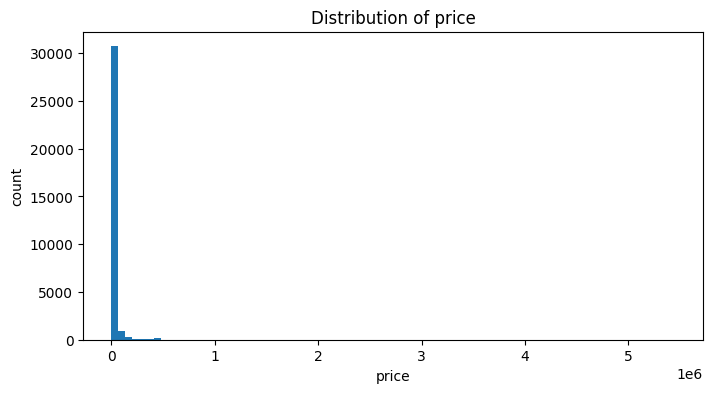

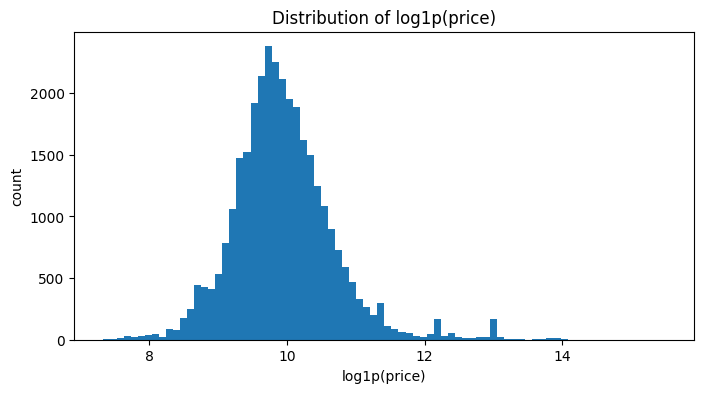

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(df['price_num'], bins=80)
plt.title('Distribution of price')
plt.xlabel('price')
plt.ylabel('count')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['log_price'], bins=80)
plt.title('Distribution of log1p(price)')
plt.xlabel('log1p(price)')
plt.ylabel('count')
plt.show()

極端な高価格物件がある場合、モデル学習では `log1p(price)` を目的変数にする、または上位1%を除外することを検討します。

In [12]:
# 例：上位1%を外れ値として除外したEDA用データ
upper = df['price_num'].quantile(0.99)
df_eda = df[df['price_num'] <= upper].copy()

print('99% upper bound:', upper)
print('df_eda shape:', df_eda.shape)

99% upper bound: 278653.02200000087
df_eda shape: (32037, 25)


## 6. カテゴリ変数の確認

In [14]:
for col in categorical_cols:
    if col in df_eda.columns:
        print('' + '='*80)
        print(col)
        display(df_eda[col].value_counts(dropna=False).head(20))

room_type


,count
room_type,
Entire home/apt,26839
Private room,4776
Shared room,312
Hotel room,110


property_type


,count
property_type,
Entire rental unit,20353
Entire home,4580
Private room in rental unit,1889
Room in hotel,1060
Private room in home,968
Entire condo,710
Room in aparthotel,465
Entire serviced apartment,401
Room in boutique hotel,235


neighbourhood_cleansed


,count
neighbourhood_cleansed,
Shinjuku Ku,5288
Sumida Ku,4757
Taito Ku,3356
Toshima Ku,2974
Shibuya Ku,2260
Ota Ku,1453
Minato Ku,1422
Katsushika Ku,1126
Nakano Ku,1066


host_is_superhost


,count
host_is_superhost,
t,17398
f,14639


instant_bookable


,count
instant_bookable,
NaN,32037


,count,mean,median
room_type,,,
Entire home/apt,26839,26772.060743,20350.0
Private room,4776,24475.295881,15000.0
Hotel room,110,13959.721182,10875.0
Shared room,312,5613.192308,3424.0


<Figure size 800x400 with 0 Axes>

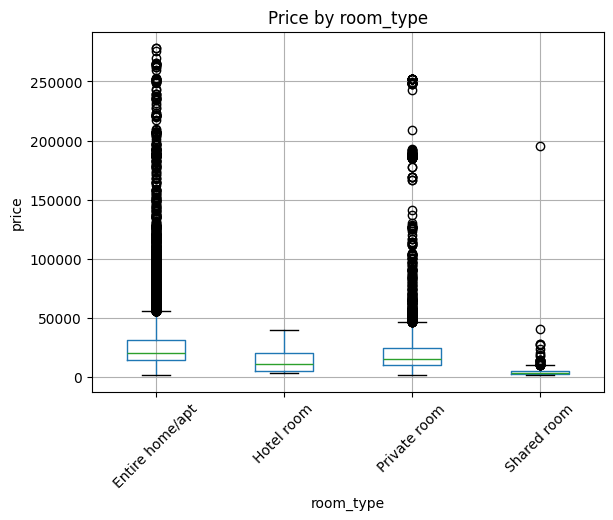

In [15]:
# room_typeごとの価格分布
if 'room_type' in df_eda.columns:
    display(df_eda.groupby('room_type')['price_num'].agg(['count', 'mean', 'median']).sort_values('median', ascending=False))

    plt.figure(figsize=(8, 4))
    df_eda.boxplot(column='price_num', by='room_type', rot=45)
    plt.title('Price by room_type')
    plt.suptitle('')
    plt.xlabel('room_type')
    plt.ylabel('price')
    plt.show()

## 7. 数値変数と価格の関係

In [16]:
num_available = [c for c in numeric_cols if c in df_eda.columns]

# 数値に変換できるものは変換
for c in num_available:
    df_eda[c] = pd.to_numeric(df_eda[c], errors='coerce')

corr = df_eda[num_available + ['price_num', 'log_price']].corr(numeric_only=True)
corr[['price_num', 'log_price']].sort_values('log_price', ascending=False)

,price_num,log_price
log_price,0.832899,1.000000
price_num,1.000000,0.832899
accommodates,0.356736,0.524135
beds,0.291961,0.417959
bedrooms,0.314665,0.413598
review_scores_rating,0.090361,0.147270
bathrooms,0.160402,0.126469
reviews_per_month,0.004427,0.042508
maximum_nights,-0.003052,0.020849
host_listings_count,0.120861,0.019310


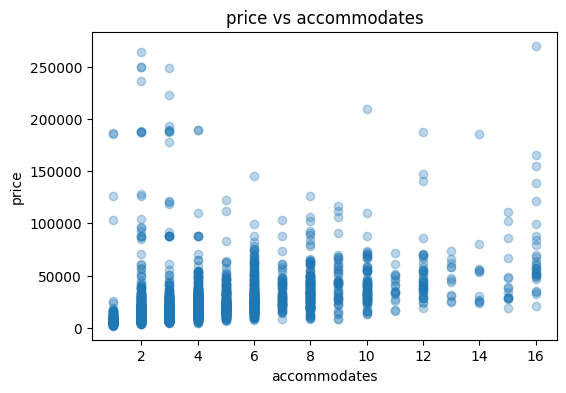

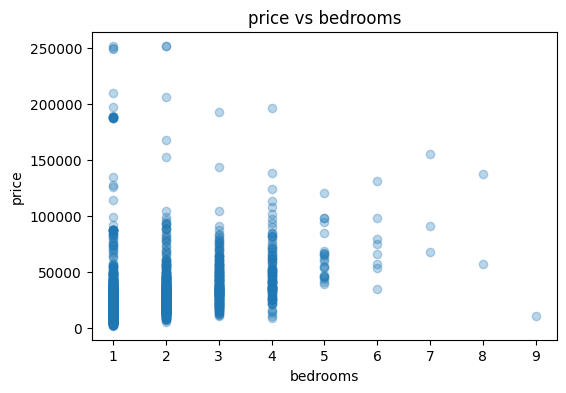

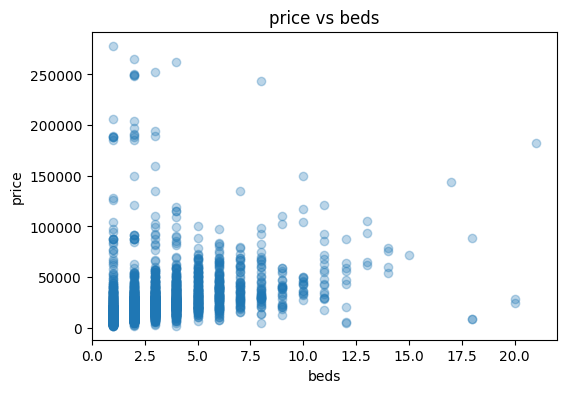

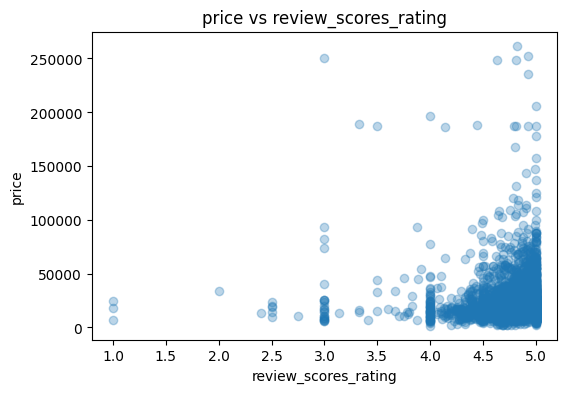

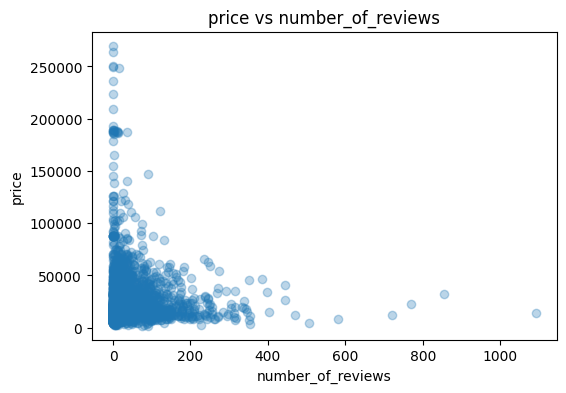

In [17]:
# 代表的な数値変数の散布図
for col in ['accommodates', 'bedrooms', 'beds', 'review_scores_rating', 'number_of_reviews']:
    if col in df_eda.columns:
        tmp = df_eda[[col, 'price_num']].dropna()
        if len(tmp) > 3000:
            tmp = tmp.sample(3000, random_state=42)
        plt.figure(figsize=(6, 4))
        plt.scatter(tmp[col], tmp['price_num'], alpha=0.3)
        plt.title(f'price vs {col}')
        plt.xlabel(col)
        plt.ylabel('price')
        plt.show()

## 8. テキスト特徴量の確認

テキストの有無、文字数、サンプルを確認します。後続のTransformer/LLM実験では、まず `description` を使うのが簡単です。

In [18]:
for col in text_cols:
    if col in df_eda.columns:
        df_eda[col] = df_eda[col].fillna('').astype(str)
        df_eda[col + '_len'] = df_eda[col].str.len()

text_len_cols = [c + '_len' for c in text_cols if c in df_eda.columns]
df_eda[text_len_cols].describe()

,name_len,description_len,neighborhood_overview_len,host_about_len
count,32037.000000,32037.000000,32037.0,32037.000000
mean,42.689422,555.913631,0.0,242.623529
std,8.859060,270.277123,0.0,259.190157
min,1.000000,0.000000,0.0,0.000000
25%,39.000000,391.000000,0.0,0.000000
50%,46.000000,506.000000,0.0,227.000000
75%,49.000000,733.000000,0.0,406.000000
max,88.000000,1000.000000,0.0,5982.000000


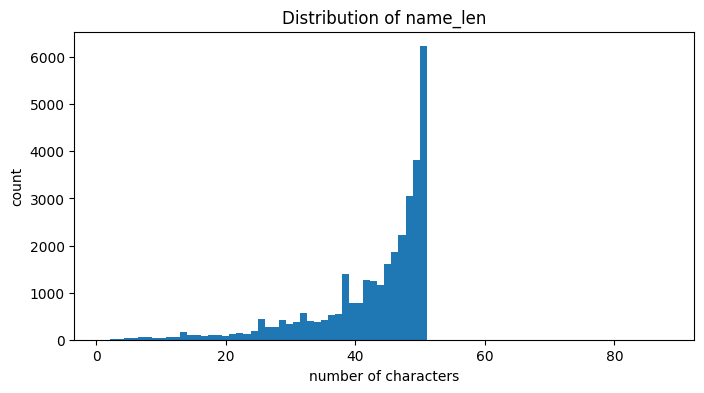

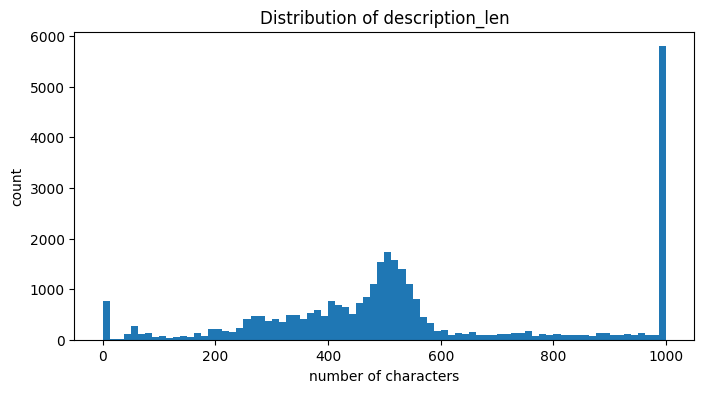

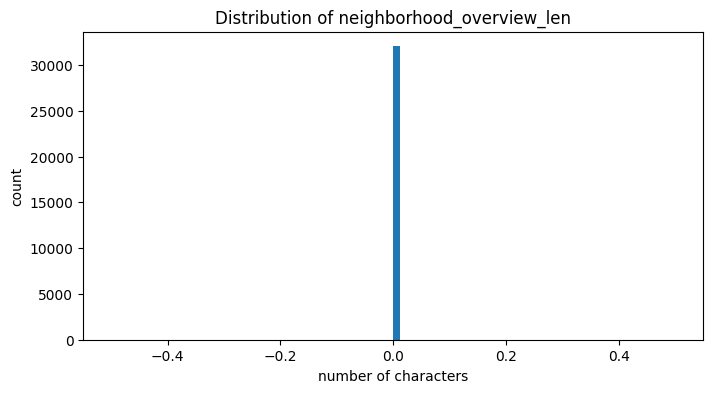

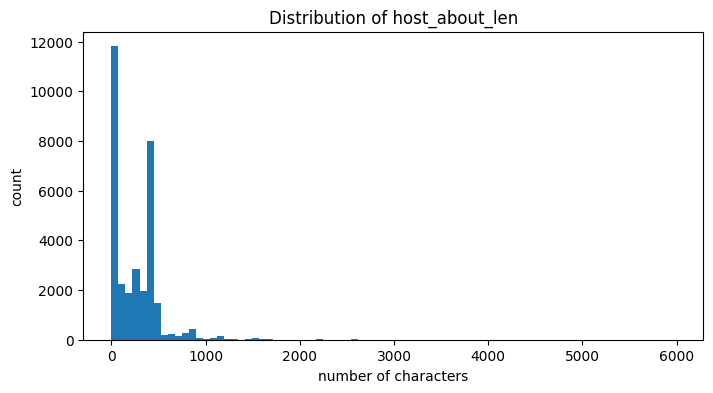

In [19]:
for col in text_len_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df_eda[col], bins=80)
    plt.title(f'Distribution of {col}')
    plt.xlabel('number of characters')
    plt.ylabel('count')
    plt.show()

In [ ]:
# descriptionのサンプル表示
sample_cols = ['price_num', 'room_type', 'property_type', 'neighbourhood_cleansed', 'description']
sample_cols = [c for c in sample_cols if c in df_eda.columns]

df_eda[sample_cols].sample(5, random_state=42)

## 9. テキスト長と価格の関係

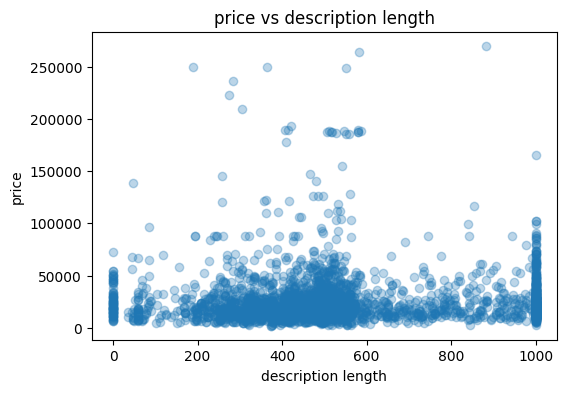

,description_len,price_num,log_price
description_len,1.000000,0.003931,0.044228
price_num,0.003931,1.000000,0.832899
log_price,0.044228,0.832899,1.000000


In [21]:
if 'description_len' in df_eda.columns:
    tmp = df_eda[['description_len', 'price_num']].dropna()
    if len(tmp) > 3000:
        tmp = tmp.sample(3000, random_state=42)

    plt.figure(figsize=(6, 4))
    plt.scatter(tmp['description_len'], tmp['price_num'], alpha=0.3)
    plt.title('price vs description length')
    plt.xlabel('description length')
    plt.ylabel('price')
    plt.show()

    display(df_eda[['description_len', 'price_num', 'log_price']].corr())

## 10. モデリング用データの作成

次の分析に進みやすいように、目的変数・テキスト・数値・カテゴリを含む小さめのデータフレームを作ります。

In [ ]:
model_cols = [
    'price_num',
    'log_price',
    'description',
    'room_type',
    'property_type',
    'neighbourhood_cleansed',
    'host_is_superhost',
    'instant_bookable',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'minimum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'availability_365',
    'latitude',
    'longitude',
]
model_cols = [c for c in model_cols if c in df_eda.columns]
model_df = df_eda[model_cols].copy()

print(model_df.shape)
model_df.head()

In [23]:
# Colab上にCSVとして保存。後続のモデリング用ノートブックで再利用できます。
OUT_PATH = 'airbnb_tokyo_model_ready_eda.csv'
model_df.to_csv(OUT_PATH, index=False)
print(f'Saved: {OUT_PATH}')

Saved: airbnb_tokyo_model_ready_eda.csv
